In [204]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 1000)
pd.options.display.float_format = '{:,.2f}'.format

from sklearn import preprocessing
from scipy.stats import chi2_contingency

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

from yellowbrick.cluster import KElbowVisualizer
from sklearn import cluster

In [205]:
df = pd.read_csv('../clustering/data/df_for_clustering.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [206]:
print("Número de registros: {}".format(df.pk_cid.count())) #442995
print("Número de ids únicos: {}".format(df.pk_cid.nunique())) #442995
print("Número de particiones únicos: {}".format(df.pk_partition.nunique())) #17

Número de registros: 442995
Número de ids únicos: 442995
Número de particiones únicos: 1


In [207]:
# Quitamos a los fallecidos:
df = df[df["deceased"]=='N']

In [208]:
df.shape

(442909, 23)

In [209]:
df_raw = df.copy()

# 1. Features Analysis and Transformation before Clustering

## Global functions

### Correlations

In [210]:
def matriz_correlacion_numeric_features(df):
    numeric_df = df.select_dtypes(include=['number'])

    correlation_matrix = numeric_df.corr(method='pearson')

    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Matriz de Correlación (Pearson)')
    plt.show()

In [211]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if min(k-1, r-1) == 0:
        return 0.0 
    return np.sqrt((chi2/n) / (min(k-1, r-1)))

def calculate_cramers_v_matrix(df, columns):
    """
    Calculates Cramér's V matrix for a list of categorical columns in a DataFrame.

    Args:
        df: The input pandas DataFrame.
        columns: A list of column names to calculate the Cramér's V matrix for.

    Returns:
        A pandas DataFrame representing the Cramér's V matrix.
    """
    cramer_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(
                    df[col1].astype(str), df[col2].astype(str)
                )
    return cramer_matrix

In [212]:
def matriz_correlacion_object_features(dfg,listdf):
  cramer_matrix = calculate_cramers_v_matrix(dfg, listdf)

  plt.figure(figsize=(8,6))
  sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="Blues")
  plt.title("Colinealidad (Cramér's V)")
  plt.show()

### Processing

In [213]:
def group_minor_categories(df, col, threshold):
    """
    Agrupa las categorías poco frecuentes de una columna en 'Other'.
    """
    df[col] = df[col].fillna('Unknown').astype(str)
    value_counts = df[col].value_counts(normalize=True)
    minor_categories = value_counts[value_counts < threshold].index
    df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')

    return df


### Feature Engineering

In [214]:
def frequency_encode(df, features_to_encode, normalize=True):
    """
    Aplica Frequency Encoding a una columna categórica,
    crea una nueva columna '<columna>_freq' y elimina la original.
    """

    for feature in features_to_encode:
        freq_encoding = df[feature].value_counts(normalize=normalize)
        new_column_name = f"{feature}_freq"
        df[new_column_name] = df[feature].map(freq_encoding)
        df.drop(columns=[feature], inplace=True)
        
    return df

In [215]:
def one_hot_encode(df, features_to_encode):
    """
    Applies one-hot encoding to a list of specified features in a DataFrame using scikit-learn.
    """
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features_to_encode])
    
    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out(features_to_encode),
        index=df.index
    )
    
    df = df.drop(columns=features_to_encode)
    df = pd.concat([df, encoded_df], axis=1)

    return df

In [216]:
def normalize_features(df, features_to_normalize):
    """
    Normalizes a list of specified features in a DataFrame to a range between 0 and 1.
    """

    scaler = MinMaxScaler()
    df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])
    
    return df

----------------------------------------------------------

In [217]:
stats = []
for col in df.columns:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])

In [218]:
filtered_stats_categoricas = stats_df[(stats_df['type'] != 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
15,loan,2,0.00,99.99,int64
22,national,2,0.00,99.96,int64
16,investment,2,0.00,98.06,int64
13,pension_plan,2,0.00,96.08,int64
14,payment_card,2,0.00,89.87,int64
18,z_active_with_product,2,0.00,74.85,int64
12,account,2,0.00,74.21,int64
17,z_num_families,6,0.00,62.50,int64
3,active_customer,2,0.00,61.28,float64
11,z_num_products,10,0.00,60.57,float64


In [219]:
filtered_stats_categoricas = stats_df[(stats_df['type'] == 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
1,pk_partition,1,0.00,100.00,object
7,deceased,1,0.00,100.00,object
4,segment,3,0.00,65.22,object
21,city_size,4,0.00,57.78,object
5,gender,2,0.00,51.40,object
2,entry_channel,65,0.00,44.98,object
19,macro_region,8,0.00,29.64,object


Decisiones:
- Borramos "deceased" por tener el 99% de los registros con el mismo valor
- Borramos "country_id" por tener el 99% de los registros con el mismo. Dejamos el region_code que está relleno cuando el pais es España y hay mas variabilidad.
- "segment" y "gender" OHE 
- "entry_channel" agrupar y luego OHE

In [220]:
df.drop(columns=['deceased'], inplace=True)

In [221]:
df.drop(columns=['gender', 'entry_channel'], inplace=True)

### 1.0 Correlations

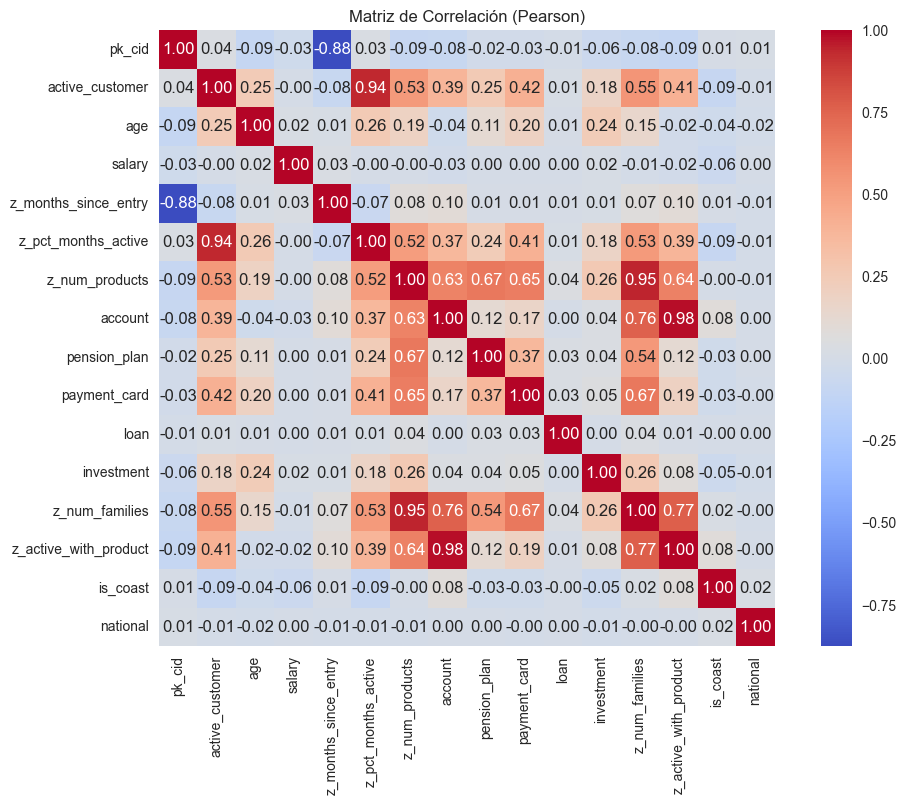

In [222]:
matriz_correlacion_numeric_features(df)

In [223]:
# Borramos "z_pct_months_active" por estar al 90% correlada con "active_customer" 
df.drop(columns=['z_pct_months_active'], inplace=True)

In [224]:
df.drop(columns=['z_num_families'], inplace=True)

In [225]:
df.drop(columns=['macro_region', 'is_coast'], inplace=True) # demasiada info de localizacion que granula mucho los clusters

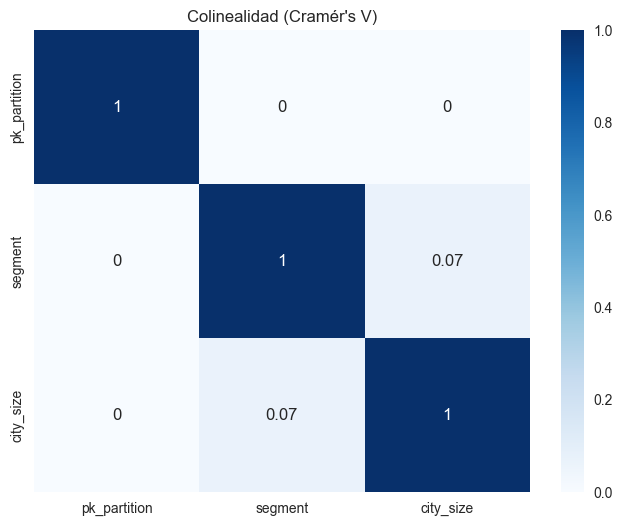

In [226]:
object_cols= df.select_dtypes(exclude=['number']).columns
matriz_correlacion_object_features(df, object_cols)

### 1.2 Encoding

In [227]:
# df = group_minor_categories(df, 'entry_channel', 0.01)
# df.drop(columns='entry_channel', inplace=True)

# df.rename(columns={'entry_channel_grouped':'entry_channel'}, inplace=True)

In [228]:
# df = group_minor_categories(df, 'region_code', 0.005)
# df.drop(columns='region_code', inplace=True)

Mejor no agrupamos la región y le hacemos el Frequency Encoding que consideramos que nos va a aportar más información.

In [229]:
# Frequency Encoding:
#freqenc_cols = ['region_code']
#df = frequency_encode(df, freqenc_cols)

In [230]:
# One Hot Encoding:
ohe_cols = ['segment','city_size']
df = one_hot_encode(df, ohe_cols)

### 1.3 Normalization

In [231]:
normalize_cols = ['age','salary','z_months_since_entry','z_num_products']

df = normalize_features(df, normalize_cols)

In [232]:
df.head()

,pk_cid,pk_partition,active_customer,age,salary,z_months_since_entry,z_num_products,account,pension_plan,payment_card,loan,investment,z_active_with_product,national,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,city_size_ciudad_mediana,city_size_extranjero,city_size_gran_ciudad,city_size_pueblo
0,1000028,2019-05-01,1.00,0.41,0.00,0.53,0.22,1,0,1,0,0,1,1,0.00,1.00,0.00,0.00,0.00,1.00,0.00
1,1000096,2019-05-01,1.00,0.08,0.00,1.00,0.00,0,0,0,0,0,0,1,0.00,1.00,0.00,0.00,0.00,1.00,0.00
2,1000113,2019-05-01,0.00,0.50,0.00,0.94,0.00,0,0,0,0,0,0,1,0.00,1.00,0.00,1.00,0.00,0.00,0.00
3,1000130,2019-05-01,1.00,0.41,0.00,0.26,0.00,0,0,0,0,0,0,1,0.00,1.00,0.00,0.00,0.00,1.00,0.00
4,1000157,2019-05-01,1.00,0.41,0.00,0.74,0.11,1,0,0,0,0,1,1,0.00,1.00,0.00,0.00,0.00,1.00,0.00


# 2. Clustering

In [233]:
print(df.shape)

(442909, 21)


## K-means

In [234]:
clustering_features = df.drop(columns=['pk_cid', 'pk_partition']).columns
clustering_features


Index(['active_customer', 'age', 'salary', 'z_months_since_entry',
       'z_num_products', 'account', 'pension_plan', 'payment_card', 'loan',
       'investment', 'z_active_with_product', 'national', 'segment_01 - TOP',
       'segment_02 - PARTICULARES', 'segment_03 - UNIVERSITARIO',
       'city_size_ciudad_mediana', 'city_size_extranjero',
       'city_size_gran_ciudad', 'city_size_pueblo'],
      dtype='object')

### PCA 1

In [235]:
from sklearn import decomposition

X = df[clustering_features]

pca = decomposition.PCA(0.9)
pca.fit(X)
x_pca = pd.DataFrame(
    pca.transform(X), columns=[f"PC{i}" for i in range(2, pca.n_components_ + 2)]
)
pca.n_components_, pca.explained_variance_ratio_.sum()

(6, 0.9203544481559451)

In [236]:
pd.DataFrame(pca.components_, columns=clustering_features)

,active_customer,age,salary,z_months_since_entry,z_num_products,account,pension_plan,payment_card,loan,investment,z_active_with_product,national,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,city_size_ciudad_mediana,city_size_extranjero,city_size_gran_ciudad,city_size_pueblo
0,0.39,0.11,0.00,-0.03,0.05,0.03,0.07,0.18,0.00,0.03,0.04,-0.00,0.02,0.61,-0.62,-0.01,0.00,0.14,-0.12
1,-0.39,0.01,0.00,-0.03,-0.09,-0.55,-0.04,-0.11,-0.00,-0.01,-0.55,0.00,-0.01,0.12,-0.11,-0.10,-0.00,0.34,-0.25
2,-0.10,0.03,-0.00,-0.01,-0.04,-0.27,-0.03,-0.05,-0.00,-0.01,-0.26,-0.00,-0.01,0.19,-0.18,0.21,0.00,-0.70,0.49
3,-0.07,-0.00,-0.00,0.00,-0.00,0.03,-0.01,-0.03,-0.00,-0.01,0.03,-0.00,-0.00,-0.00,0.01,0.78,0.00,-0.19,-0.59
4,0.73,-0.05,0.00,-0.18,0.02,-0.35,0.09,0.24,0.00,0.03,-0.32,0.00,0.04,-0.27,0.24,0.06,-0.00,-0.02,-0.04
5,-0.17,0.00,0.00,0.66,0.14,-0.07,0.24,0.66,0.00,-0.02,-0.05,-0.00,-0.04,-0.02,0.06,0.01,0.00,-0.02,0.01


In [237]:
# Crea un DataFrame con las cargas de cada variable en cada componente
loadings = pd.DataFrame(
    pca.components_,
    columns=clustering_features,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Visualiza los 5 valores más altos (positivos o negativos) para cada PC
for i, row in loadings.iterrows():
    print(f"\n{i} - Top features:")
    print(row.abs().sort_values(ascending=False).head(5))


PC1 - Top features:
segment_03 - UNIVERSITARIO   0.62
segment_02 - PARTICULARES    0.61
active_customer              0.39
payment_card                 0.18
city_size_gran_ciudad        0.14
Name: PC1, dtype: float64

PC2 - Top features:
account                 0.55
z_active_with_product   0.55
active_customer         0.39
city_size_gran_ciudad   0.34
city_size_pueblo        0.25
Name: PC2, dtype: float64

PC3 - Top features:
city_size_gran_ciudad      0.70
city_size_pueblo           0.49
account                    0.27
z_active_with_product      0.26
city_size_ciudad_mediana   0.21
Name: PC3, dtype: float64

PC4 - Top features:
city_size_ciudad_mediana   0.78
city_size_pueblo           0.59
city_size_gran_ciudad      0.19
active_customer            0.07
account                    0.03
Name: PC4, dtype: float64

PC5 - Top features:
active_customer             0.73
account                     0.35
z_active_with_product       0.32
segment_02 - PARTICULARES   0.27
payment_card            

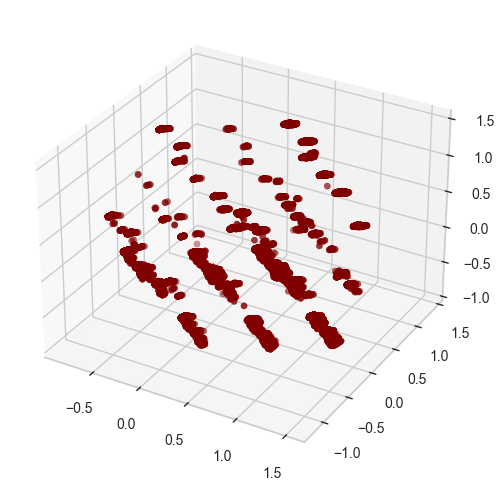

In [238]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xs=x_pca.iloc[:, 0],
    ys=x_pca.iloc[:, 1],
    zs=x_pca.iloc[:, 2],
    c="maroon",
    marker="o",
)
plt.show()

### 1. Kmeans Clustering

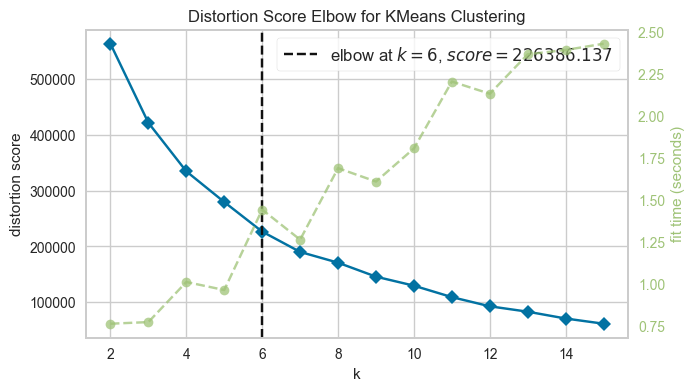

In [239]:
fig, ax = plt.subplots(figsize=(7, 4))
Elbow_M = KElbowVisualizer(cluster.KMeans(n_init=10), k=15, ax=ax)
Elbow_M.fit(x_pca)
Elbow_M.show()
plt.show()

In [240]:
kmeans = cluster.KMeans(n_clusters=Elbow_M.elbow_value_, n_init=10)
# kmeans = cluster.KMeans(n_clusters=6, n_init=10)
kmeans.fit(x_pca)
clusters = kmeans.predict(x_pca) + 1

In [241]:
# Guardar modelos entrenados
import joblib

#joblib.dump(pca, 'models/pca_model.pkl')
#joblib.dump(kmeans, 'models/kmeans_model.pkl')

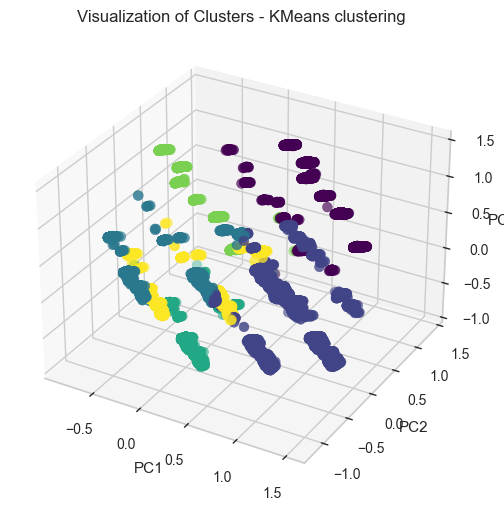

In [242]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xs=x_pca.iloc[:, 0],
    ys=x_pca.iloc[:, 1],
    zs=x_pca.iloc[:, 2],
    marker="o",
    c=clusters,
    s=50,
    cmap="viridis",
)
ax.set(
    xlabel="PC1",
    ylabel="PC2",
    zlabel="PC3",
    title="Visualization of Clusters - KMeans clustering",
)
plt.show()

In [243]:
df["cluster"] = kmeans.predict(x_pca) + 1

In [244]:
df["cluster"].value_counts().sort_index()

cluster
1     47640
2     97050
3     74942
4    113726
5     63795
6     45756
Name: count, dtype: int64

In [264]:
cluster_names = {
    1: "Particulares sin cuenta",       
    2: "Particulares Premium Digitales",     
    3: "Jóvenes Recientes",     
    4: "Jóvenes Potenciales",    
    5: "Leads Jóvenes",       
    6: "Jóvenes Básicos Activos"       
}

df['cluster_name'] = df['cluster'].map(cluster_names)

print("\n🏷️ NOMBRES ASIGNADOS:\n")
for k, v in cluster_names.items():
    size = len(df[df['cluster']==k])
    pct = size/len(df)*100
    print(f"Cluster {k}: {v:30s} ({size:,} clientes, {pct:.1f}%)")


🏷️ NOMBRES ASIGNADOS:

Cluster 1: Particulares sin cuenta        (47,640 clientes, 10.8%)
Cluster 2: Particulares Premium Digitales (97,050 clientes, 21.9%)
Cluster 3: Jóvenes Recientes              (74,942 clientes, 16.9%)
Cluster 4: Jóvenes Potenciales            (113,726 clientes, 25.7%)
Cluster 5: Leads Jóvenes                  (63,795 clientes, 14.4%)
Cluster 6: Jóvenes Básicos Activos        (45,756 clientes, 10.3%)


In [263]:
df[['pk_cid', 'cluster_name']].drop_duplicates().to_csv('../clustering/data/processed/df_clustered.csv', index=False)

### - Interpretation

Unimos el dataframe original (con el sin procesar) para saber interpretar bien los clusters con cada variable antes de la estandarización + otras variables agrupadas que he creado.

In [246]:
new_cols = [col for col in df.columns if col not in df_raw.columns] # todas las columnas que no esten en df_input_original_cols, es decir, o transformaciones o agrupamientos
df_merged = pd.merge(df_raw, df[new_cols], left_index=True, right_index=True)

In [247]:
df_merged.columns

Index(['pk_cid', 'pk_partition', 'entry_channel', 'active_customer', 'segment',
       'gender', 'age', 'deceased', 'salary', 'z_months_since_entry',
       'z_pct_months_active', 'z_num_products', 'account', 'pension_plan',
       'payment_card', 'loan', 'investment', 'z_num_families',
       'z_active_with_product', 'macro_region', 'is_coast', 'city_size',
       'national', 'segment_01 - TOP', 'segment_02 - PARTICULARES',
       'segment_03 - UNIVERSITARIO', 'city_size_ciudad_mediana',
       'city_size_extranjero', 'city_size_gran_ciudad', 'city_size_pueblo',
       'cluster'],
      dtype='object')

In [254]:
interpretation_cols = [#'entry_channel', 
       'active_customer', 'segment',
       #'gender', 
       'age', 'salary', 'z_months_since_entry',
       #'z_pct_months_active', 
       'z_num_products',
       'payment_card', 'account', 'pension_plan', 'loan', 'investment', 'z_num_families',
       'z_active_with_product', 
       'city_size', #'macro_region',
       'national',
       'cluster']

In [255]:
# for col in df_merged[interpretation_cols].columns:
#     if df_merged[col].nunique() == 2 and set(df_merged[col].dropna().unique()).issubset({0, 1}):
#         df_merged[col] = df_merged[col].map({1: 'SI', 0: 'NO'})

In [256]:
df_merged[interpretation_cols]

,active_customer,segment,age,salary,z_months_since_entry,z_num_products,payment_card,account,pension_plan,loan,investment,z_num_families,z_active_with_product,city_size,national,cluster
0,1.00,02 - PARTICULARES,44,"133,378.89",28.00,2.00,1,1,0,0,0,2,1,gran_ciudad,1,2
1,1.00,02 - PARTICULARES,10,0.00,53.00,0.00,0,0,0,0,0,0,0,gran_ciudad,1,1
2,0.00,02 - PARTICULARES,54,"136,705.50",50.00,0.00,0,0,0,0,0,0,0,ciudad_mediana,1,1
3,1.00,02 - PARTICULARES,44,"126,133.50",14.00,0.00,0,0,0,0,0,0,0,gran_ciudad,1,1
4,1.00,02 - PARTICULARES,44,"68,038.20",39.00,1.00,0,1,0,0,0,1,1,gran_ciudad,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442990,1.00,02 - PARTICULARES,44,"126,242.40",49.00,6.00,1,1,1,0,0,3,1,gran_ciudad,1,2
442991,0.00,02 - PARTICULARES,14,0.00,5.00,0.00,0,0,0,0,0,0,0,gran_ciudad,1,1
442992,1.00,02 - PARTICULARES,40,"108,659.43",28.00,1.00,0,1,0,0,0,1,1,ciudad_mediana,1,2
442993,1.00,02 - PARTICULARES,32,"111,945.96",40.00,1.00,0,0,0,0,1,1,1,gran_ciudad,1,2


In [257]:
df_merged.dtypes

pk_cid                          int64
pk_partition                   object
entry_channel                  object
active_customer               float64
segment                        object
gender                         object
age                             int64
deceased                       object
salary                        float64
z_months_since_entry          float64
z_pct_months_active           float64
z_num_products                float64
account                         int64
pension_plan                    int64
payment_card                    int64
loan                            int64
investment                      int64
z_num_families                  int64
z_active_with_product           int64
macro_region                   object
is_coast                        int64
city_size                      object
national                        int64
segment_01 - TOP              float64
segment_02 - PARTICULARES     float64
segment_03 - UNIVERSITARIO    float64
city_size_ci

In [258]:
categorical_features = df_merged[interpretation_cols].select_dtypes(include=["object", "category"]).columns

summary_dict = {}
for col in categorical_features:
    summary_dict[col] = df_merged.groupby('cluster')[col].agg(
        count='count',
        n_unique=pd.Series.nunique,
        top=lambda x: x.mode()[0] if not x.mode().empty else None,
        freq=lambda x: x.value_counts().iloc[0] if not x.empty else 0
    )

df_categorical_summary = pd.concat(summary_dict, axis=1)
df_categorical_summary.T.style.background_gradient(cmap='Blues', axis=1)

* Representación variables numéricas

In [259]:
numeric_features = df_merged[interpretation_cols].select_dtypes(include=["number"]).columns

In [260]:
percentiles = [0.25, 0.50, 0.75, 0.95]

df_numeric_summary = (
    df_merged[numeric_features]
    .groupby(df_merged['cluster'])
    .agg(
        ['max', 'min', 'mean', 'median']
        + [(f"p{int(p*100)}", lambda x, p=p: x.quantile(p)) for p in percentiles]
    )
)

df_numeric_summary.T.style.background_gradient(cmap='Reds', axis=1)